# Generalized Tikhonov Regularization & Error Analysis

**Mathematics for Imaging and Signal Processing, A.A. 2025/2026**

We recover a sharp image $f$ from a blurred, noisy observation $g = A f + w$, where $A$ is
convolution with a Point Spread Function (PSF). In the Fourier domain the model is pointwise:

$$\hat g(\omega) = \hat K(\omega)\,\hat f(\omega) + \hat w(\omega).$$

Direct inversion $\hat g/\hat K$ is ill-posed (noise is amplified where $\hat K\to 0$), so we use
**generalized Tikhonov regularization**

$$\hat f_\mu(\omega) = \frac{\hat K^*(\omega)}{|\hat K(\omega)|^2 + \mu\,|P(\omega)|^2}\,\hat g(\omega),$$

with penalties $L^2$ ($|P|^2=1$), $H^1$ ($|P|^2=|\omega|^2$) and $H^2$ ($|P|^2=|\omega|^4$).

The notebook is organized in four parts:

1. **Forward problem:** simulate blur and noise at 40 dB and 20 dB.
2. **Generalized Tikhonov:** compare $L^2$, $H^1$, $H^2$ reconstructions with edge zoom-ins.
3. **Spectral windowing:** hard cutoff (TSVD) vs the smooth Tikhonov filter.
4. **Bias-variance trade-off:** split the error into approximation and noise terms vs $\mu$.

The numerical routines live in `tikhonov_deblurring.py` (imported as `td`); the notebook calls them
and plots the results.

## Setup

Load the image, build the centered frequency grid, and construct the two blur transfer functions:
a **Gaussian** blur (smooth, no zeros) and a **linear motion** blur (directional, with
transfer-function zeros).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import tikhonov_deblurring as td

fftshift = np.fft.fftshift

# Built-in image. To use your own picture later: td.load_image("data/your_image.png")
f0 = td.load_image()

# Centered frequency grid and the two transfer functions (FFT layout).
wX, wY, w_radius = td.make_centered_grid(*f0.shape)
w_radius_fft = td.to_fft_layout(w_radius)
K_gauss = td.gaussian_tf(wX, wY)
K_motion = td.motion_tf(wX, wY)

print(f"image shape   : {f0.shape}")
print(f"intensity range: [{f0.min():.3f}, {f0.max():.3f}]")
print(f"Gaussian sigma : {td.GAUSS_SIGMA},  motion length L : {td.MOTION_L} px")
print(f"SNR scenarios  : {td.SNR_HIGH_DB:.0f} dB (high), {td.SNR_LOW_DB:.0f} dB (low)")

image shape   : (256, 256)
intensity range: [0.000, 1.000]
Gaussian sigma : 4.0,  motion length L : 21 px
SNR scenarios  : 40 dB (high), 20 dB (low)


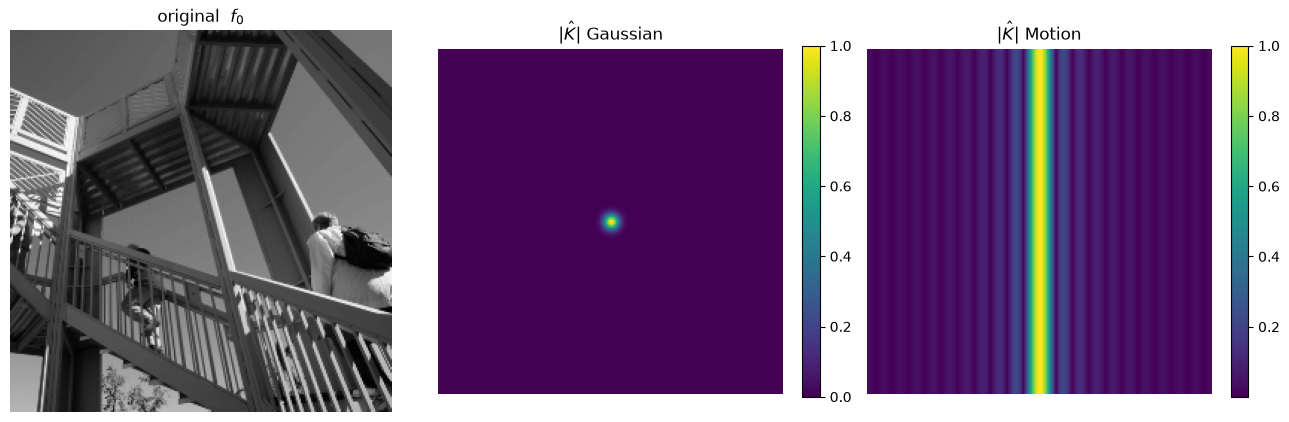

In [2]:
# The sharp image and the magnitudes of the two transfer functions (DC centered for viewing).
fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
ax[0].imshow(f0, cmap="gray", vmin=0, vmax=1); ax[0].set_title("original  $f_0$")
im1 = ax[1].imshow(fftshift(np.abs(K_gauss)), cmap="viridis"); ax[1].set_title(r"$|\hat K|$ Gaussian")
im2 = ax[2].imshow(fftshift(np.abs(K_motion)), cmap="viridis"); ax[2].set_title(r"$|\hat K|$ Motion")
for a in ax: a.axis("off")
fig.colorbar(im1, ax=ax[1], fraction=0.046); fig.colorbar(im2, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.show()

## Part 1: The Forward Problem (Simulation)

We blur $f_0$ and add zero-mean Gaussian noise calibrated to a target SNR,
$\sigma_{\text{noise}} = 10^{-\text{SNR}_{dB}/20}\,\operatorname{std}(g_{\text{clean}})$
(Appendix Alg. 2), in a high-SNR (40 dB) and a low-SNR (20 dB) scenario. Both blurs are simulated:
Gaussian (isotropic) and linear motion (horizontal smear, with transfer-function zeros). Parts 2 to 4
use the motion blur, whose zeros make the deblurring and the ringing effects more visible.

The last figure shows the naive inverse $\hat g/\hat K$: dividing white noise by a transfer function
that decays to $\approx 0$ amplifies high frequencies without bound, so the reconstruction blows up.
This is what motivates regularization.

Gaussian target   40 dB  ->  measured 40.00 dB
Gaussian target   20 dB  ->  measured 20.00 dB
Motion   target   40 dB  ->  measured 40.00 dB
Motion   target   20 dB  ->  measured 20.00 dB


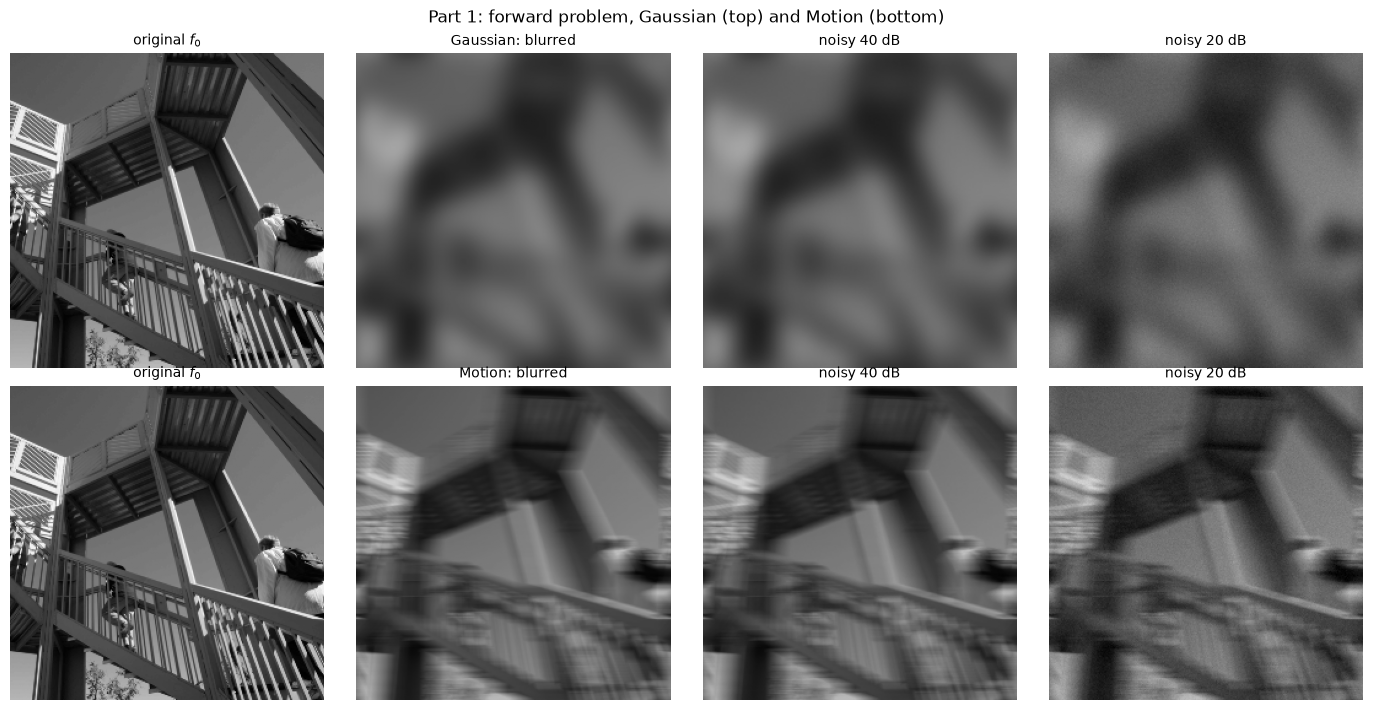

In [3]:
# Forward problem for both blurs at both SNR levels (fresh, seeded RNG per simulation).
BLURS = {"Gaussian": K_gauss, "Motion": K_motion}
SNRS = (td.SNR_HIGH_DB, td.SNR_LOW_DB)
sims = {name: {snr: td.simulate_forward(f0, K, snr, np.random.default_rng(td.SEED)) for snr in SNRS}
        for name, K in BLURS.items()}

for name in BLURS:
    for snr in SNRS:
        s = sims[name][snr]
        print(f"{name:8s} target {snr:>4.0f} dB  ->  measured "
              f"{td.measure_snr_db(s['g_clean'], s['g_noisy']):.2f} dB")

# 2 rows (Gaussian, Motion) x [original, blurred, 40 dB, 20 dB].
fig, ax = plt.subplots(2, 4, figsize=(14, 7.2))
for r, name in enumerate(BLURS):
    cols = [(f0, "original $f_0$"), (sims[name][td.SNR_HIGH_DB]["g_clean"], f"{name}: blurred"),
            (sims[name][td.SNR_HIGH_DB]["g_noisy"], "noisy 40 dB"),
            (sims[name][td.SNR_LOW_DB]["g_noisy"], "noisy 20 dB")]
    for c, (im, title) in enumerate(cols):
        ax[r, c].imshow(im, cmap="gray", vmin=0, vmax=1); ax[r, c].set_title(title, fontsize=10)
        ax[r, c].axis("off")
fig.suptitle("Part 1: forward problem, Gaussian (top) and Motion (bottom)")
plt.tight_layout(); plt.show()

naive inverse range: [-8.6, 9.6]  (blown up far outside [0, 1])


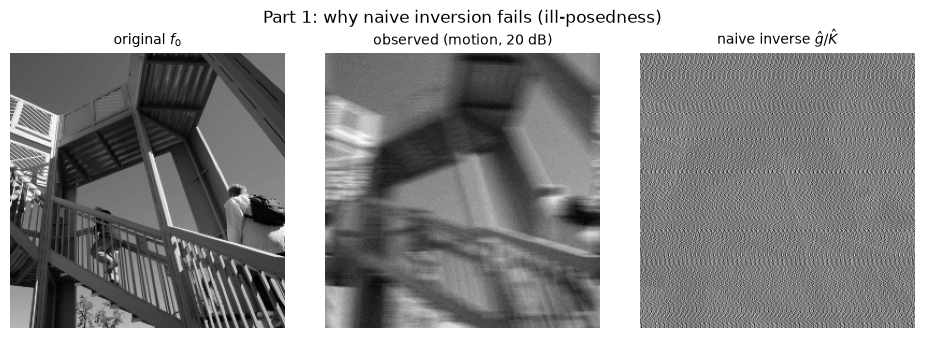

In [4]:
# The failure of naive inversion (motion blur, 20 dB): noise amplified without bound.
g_lo_m = sims["Motion"][td.SNR_LOW_DB]["g_noisy"]
naive = td.naive_inverse(g_lo_m, K_motion)
print(f"naive inverse range: [{naive.min():.1f}, {naive.max():.1f}]  (blown up far outside [0, 1])")
td.show_images([f0, g_lo_m, naive],
               ["original $f_0$", "observed (motion, 20 dB)", "naive inverse $\\hat g/\\hat K$"],
               ncols=3, vmin=None, vmax=None,
               suptitle="Part 1: why naive inversion fails (ill-posedness)")
plt.show()

## Part 2: Generalized Tikhonov ($L^2$ / $H^1$ / $H^2$)

We reconstruct with the three penalties. The useful $\mu$ scale differs by orders of magnitude
between methods ($|P|^2$ is $1$ vs $|\omega|^2$ vs $|\omega|^4$), so each method is shown at its own
PSNR-optimal $\mu$, searched over a method-specific grid. We compare the full images and zoom in on an
edge to see how each penalty trades edge sharpness against noise suppression.

In [5]:
# Penalty masks (FFT layout) and per-method mu search grids.
penalties = {m: td.penalty_squared(m, wX, wY) for m in ("L2", "H1", "H2")}
MU_SEARCH = {
    "L2": np.logspace(-6, 0, 40),     # |P|^2 = 1
    "H1": np.logspace(-10, -2, 40),   # |P|^2 = |omega|^2
    "H2": np.logspace(-15, -6, 40),   # |P|^2 = |omega|^4
}

def reconstruct_all(g, K_hat):
    # Best-PSNR L2/H1/H2 reconstructions of g. Returns (recs, mus).
    recs, mus = {}, {}
    for m in ("L2", "H1", "H2"):
        mu, _ = td.best_mu_by_psnr(f0, g, K_hat, penalties[m], MU_SEARCH[m])
        mus[m] = mu
        recs[m] = td.tikhonov_filter(g, K_hat, penalties[m], mu)
    return recs, mus

# Primary blur for the analysis parts: motion (its zeros make the differences clearest).
PRIMARY = "Motion"
K_prim = BLURS[PRIMARY]

# Reconstruct both SNR scenarios and keep the results.
part2 = {snr: reconstruct_all(sims[PRIMARY][snr]["g_noisy"], K_prim) for snr in SNRS}

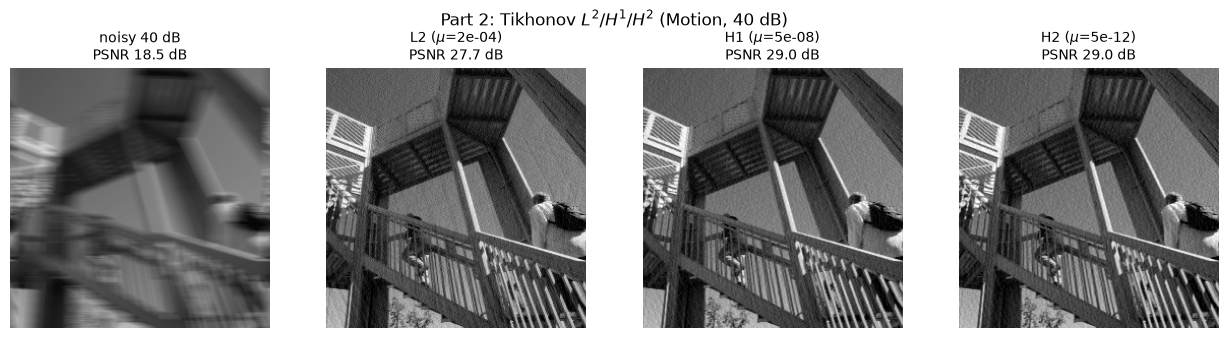

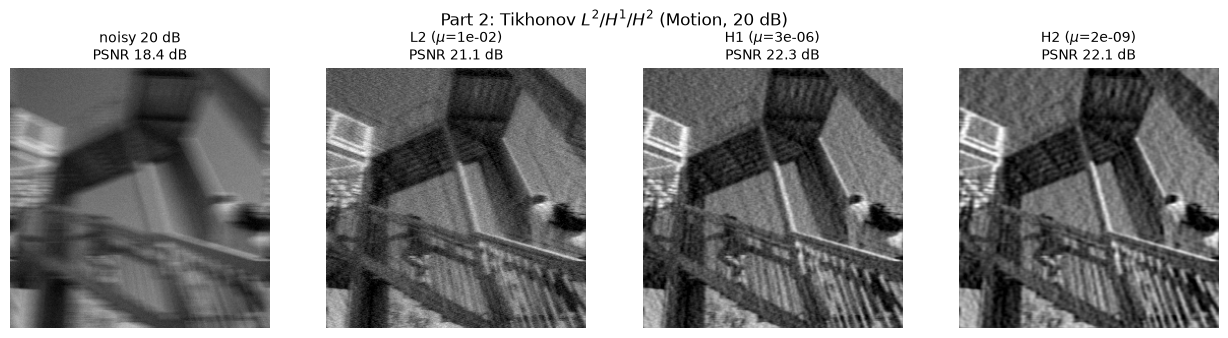

In [6]:
# Full-image comparison for each SNR scenario (motion blur).
for snr in SNRS:
    g = sims[PRIMARY][snr]["g_noisy"]
    recs, mus = part2[snr]
    panels = [g, recs["L2"], recs["H1"], recs["H2"]]
    titles = [f"noisy {snr:.0f} dB\nPSNR {td.psnr(f0, g):.1f} dB"] + [
        f"{m} ($\\mu$={mus[m]:.0e})\nPSNR {td.psnr(f0, recs[m]):.1f} dB" for m in ("L2", "H1", "H2")]
    td.show_images(panels, titles, ncols=4,
                   suptitle=f"Part 2: Tikhonov $L^2$/$H^1$/$H^2$ ({PRIMARY}, {snr:.0f} dB)")
    plt.show()

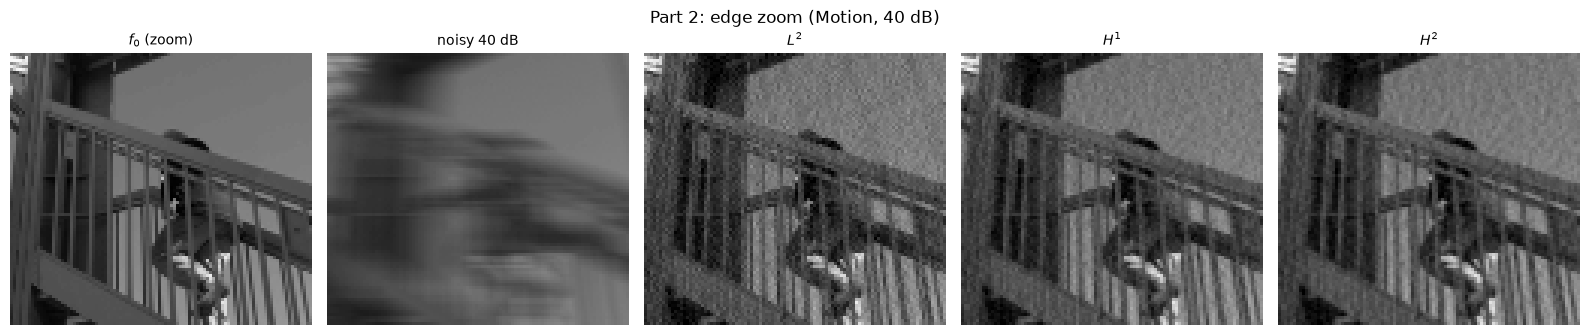

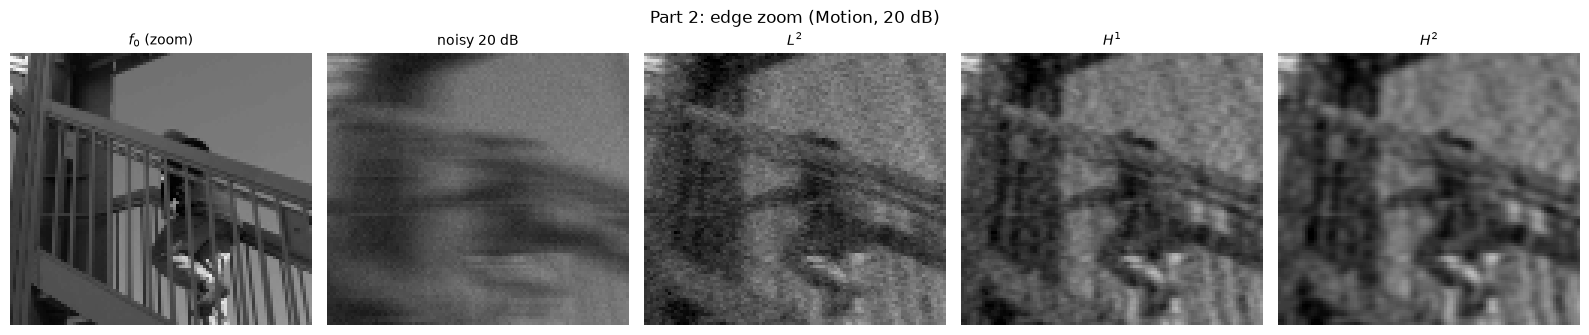

In [7]:
# Edge zoom-in: how L2/H1/H2 preserve a sharp edge, at both noise levels.
box = (118, 208, 28, 128)   # railing region with strong vertical edges; (r0, r1, c0, c1)
for snr in SNRS:
    g = sims[PRIMARY][snr]["g_noisy"]
    recs, _ = part2[snr]
    panels = [td.zoom(im, box) for im in (f0, g, recs["L2"], recs["H1"], recs["H2"])]
    titles = ["$f_0$ (zoom)", f"noisy {snr:.0f} dB", "$L^2$", "$H^1$", "$H^2$"]
    td.show_images(panels, titles, ncols=5,
                   suptitle=f"Part 2: edge zoom ({PRIMARY}, {snr:.0f} dB)")
    plt.show()


In [8]:
# Metrics table: PSNR (dB) and relative L2 error for each method and scenario.
print(f"{'method':<6} | {'40 dB PSNR':>10} {'40 dB relL2':>11} | {'20 dB PSNR':>10} {'20 dB relL2':>11}")
print("-" * 60)
for m in ("L2", "H1", "H2"):
    cells_row = []
    for snr in (td.SNR_HIGH_DB, td.SNR_LOW_DB):
        rec = part2[snr][0][m]
        cells_row += [f"{td.psnr(f0, rec):>10.2f}", f"{td.relative_l2_error(rec, f0):>11.4f}"]
    print(f"{m:<6} | {cells_row[0]} {cells_row[1]} | {cells_row[2]} {cells_row[3]}")
# Baseline (no deblurring) for reference.
for snr in SNRS:
    g = sims[PRIMARY][snr]["g_noisy"]
    print(f"observed {snr:.0f} dB: PSNR {td.psnr(f0, g):.2f} dB, relL2 {td.relative_l2_error(g, f0):.4f}")

method | 40 dB PSNR 40 dB relL2 | 20 dB PSNR 20 dB relL2
------------------------------------------------------------
L2     |      27.69      0.1045 |      21.10      0.2234
H1     |      28.99      0.0901 |      22.28      0.1948
H2     |      28.99      0.0900 |      22.07      0.1996
observed 40 dB: PSNR 18.49 dB, relL2 0.3015
observed 20 dB: PSNR 18.43 dB, relL2 0.3036


## Part 3: Spectral Windowing (hard cutoff vs Tikhonov)

The truncated-SVD equivalent keeps frequencies inside a disk and inverts there,
$\hat f_\Omega = \hat W_\Omega\,\hat g/\hat K$ with $\hat W_\Omega(\omega)=\mathbb{1}[|\omega|<\Omega]$.
Its abrupt brick-wall edge produces ringing (Gibbs oscillations), unlike the smooth roll-off of the
Tikhonov filter. We use the motion blur at high SNR (40 dB) so the ringing, which comes from the
spectral truncation itself and not from noise, is not masked. The motion transfer-function zero sits
at $|\omega|\approx N/L\approx 12$, so cutoffs above it also start amplifying noise at that zero.

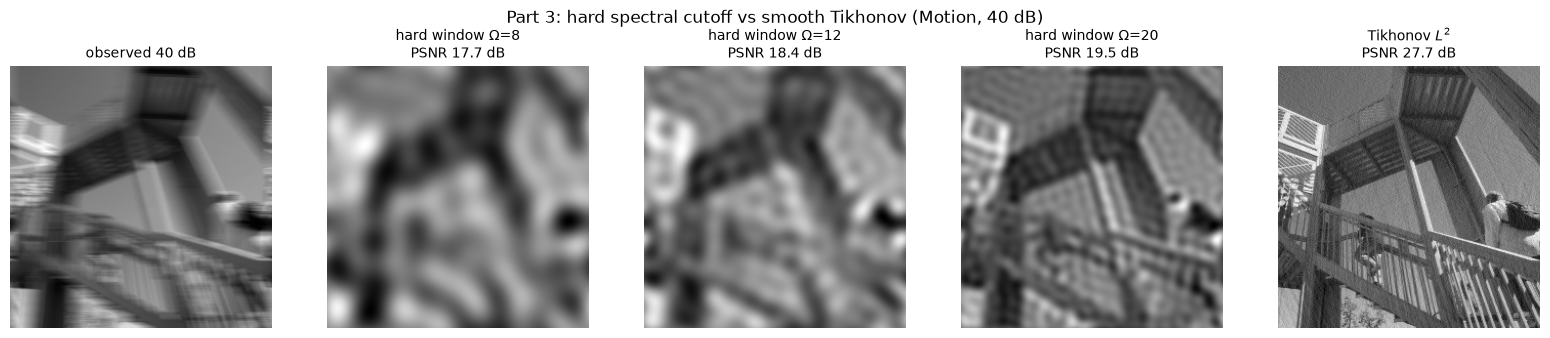

In [9]:
# Motion blur at 40 dB: hard windows at several cutoffs vs smooth Tikhonov (L2).
snr_p3 = td.SNR_HIGH_DB
g_m = sims["Motion"][snr_p3]["g_noisy"]   # same seeded simulation as Part 1
omegas = [8, 12, 20]
win_recs = [td.spectral_window_reconstruction(g_m, K_motion, w_radius_fft, O) for O in omegas]
mu_L2, _ = td.best_mu_by_psnr(f0, g_m, K_motion, penalties["L2"], MU_SEARCH["L2"])
tik_L2 = td.tikhonov_filter(g_m, K_motion, penalties["L2"], mu_L2)

panels = [g_m] + win_recs + [tik_L2]
titles = [f"observed {snr_p3:.0f} dB"] + \
         [f"hard window $\\Omega$={O}\nPSNR {td.psnr(f0, r):.1f} dB" for O, r in zip(omegas, win_recs)] + \
         [f"Tikhonov $L^2$\nPSNR {td.psnr(f0, tik_L2):.1f} dB"]
td.show_images(panels, titles, ncols=5, vmin=None, vmax=None,
               suptitle=f"Part 3: hard spectral cutoff vs smooth Tikhonov (Motion, {snr_p3:.0f} dB)")
plt.show()

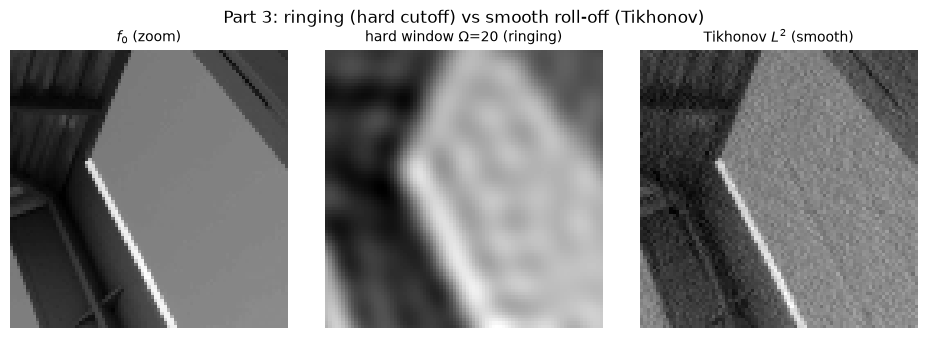

In [10]:
# Zoom to expose ringing: a wide hard window vs the smooth Tikhonov filter.
box = (35, 120, 150, 235)
panels = [td.zoom(im, box) for im in (f0, win_recs[-1], tik_L2)]
titles = ["$f_0$ (zoom)", f"hard window $\\Omega$={omegas[-1]} (ringing)", "Tikhonov $L^2$ (smooth)"]
td.show_images(panels, titles, ncols=3, vmin=None, vmax=None,
               suptitle="Part 3: ringing (hard cutoff) vs smooth roll-off (Tikhonov)")
plt.show()

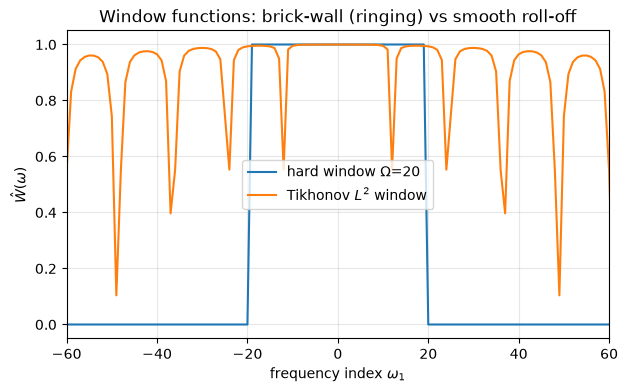

In [11]:
# 1-D radial slice of the two window functions: brick-wall vs smooth Tikhonov roll-off.
W_tik = fftshift(td.window_function(K_motion, penalties["L2"], mu_L2))
W_hard = fftshift((w_radius_fft < omegas[-1]).astype(float))
mid = f0.shape[0] // 2
xs = np.arange(-f0.shape[1] // 2, f0.shape[1] // 2)
plt.figure(figsize=(7, 4))
plt.plot(xs, W_hard[mid], label=f"hard window $\\Omega$={omegas[-1]}")
plt.plot(xs, W_tik[mid], label="Tikhonov $L^2$ window")
plt.xlabel(r"frequency index $\omega_1$"); plt.ylabel(r"$\hat W(\omega)$")
plt.title("Window functions: brick-wall (ringing) vs smooth roll-off")
plt.xlim(-60, 60); plt.grid(alpha=0.3); plt.legend(); plt.show()

## Part 4: The Bias-Variance Trade-off

The reconstruction error splits into two competing terms (Eq. 100-101):

$$\text{Error}^2(\mu) = \underbrace{\|(R_\mu A - I) f_0\|^2}_{\text{Approximation (Bias)}}
+ \underbrace{\|R_\mu w\|^2}_{\text{Noise (Variance)}}.$$

As $\mu$ grows the bias rises (over-smoothing) and the variance falls (less noise amplification). The
optimal $\mu$ minimizes the total error, at the bias = variance crossover. We fix the $H^1$ penalty
(motion blur) and show both SNR scenarios.

**On the $\mu$ range.** The assignment suggests $\mu \in [10^{-6}, 1]$ as an example. Following
Appendix Algorithm 3, the penalty $|P(\omega)|^2 = \omega_1^2 + \omega_2^2$ is built on the raw
integer frequency grid (indices up to $N/2 = 128$, so $|P|^2$ reaches $\approx 3.3\cdot10^4$ at the
grid edge). With this scaling the $H^1$ optimum lands near $10^{-8}$ to $10^{-6}$, so we sweep
$\mu \in [10^{-9}, 10^{-1}]$: the same logarithmic range, shifted so the optimum is bracketed with
both tails visible.

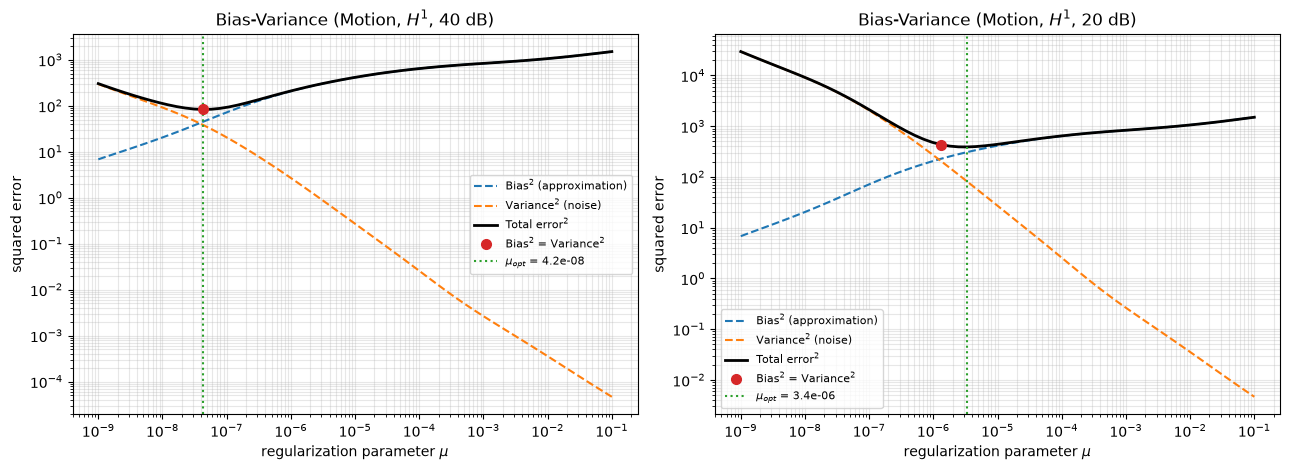

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, snr in zip(axes, SNRS):
    sim = sims[PRIMARY][snr]   # reuse the Part 1 simulation (same seed, same noise)
    curves = td.bias_variance_curves(f0, K_motion, sim["noise"], penalties["H1"], td.MU_GRID)
    mu_opt = td.optimal_mu(td.MU_GRID, curves["total"])
    td.plot_bias_variance(td.MU_GRID, curves["bias"], curves["variance"], curves["total"],
                          mu_opt, ax=ax, title=f"Bias-Variance (Motion, $H^1$, {snr:.0f} dB)")
plt.tight_layout(); plt.show()


In [13]:
# Verify: the total-error minimum coincides with the Bias = Variance crossover.
for snr in SNRS:
    c = td.bias_variance_curves(f0, K_motion, sims[PRIMARY][snr]["noise"], penalties["H1"], td.MU_GRID)
    i_opt = int(np.argmin(c["total"]))
    i_cross = int(np.argmin(np.abs(c["bias"] - c["variance"])))
    print(f"{snr:>4.0f} dB:  mu_opt = {td.MU_GRID[i_opt]:.2e} (idx {i_opt}),  "
          f"crossover = {td.MU_GRID[i_cross]:.2e} (idx {i_cross})")


  40 dB:  mu_opt = 4.24e-08 (idx 12),  crossover = 4.24e-08 (idx 12)
  20 dB:  mu_opt = 3.35e-06 (idx 26),  crossover = 1.31e-06 (idx 23)


## Discussion: smoothness order vs edge preservation

**Penalty order: edge preservation vs noise suppression.** The Tikhonov filter is a soft,
frequency-dependent low-pass (Eq. 112), $\hat W_\mu = |\hat K|^2/(|\hat K|^2+\mu|P|^2)$, close to $1$
where the signal dominates and close to $0$ where noise does. The penalty order sets how fast the
window decays:

- **$L^2$** ($|P|^2=1$): damps high frequencies roughly uniformly. Sharpest edges of the three, but
  the grainiest (least noise suppression).
- **$H^1$** ($|P|^2=|\omega|^2$, penalizes $\|\nabla f\|^2$): stronger high-frequency damping, so a
  smoother result with softened edges and good noise suppression (Sobolev $H^1$).
- **$H^2$** ($|P|^2=|\omega|^4$, penalizes the Hessian): the window decays as $|\omega|^{-4}$, giving
  very aggressive high-frequency suppression. Smoothest result and best denoising in flat regions, but
  the worst edge fidelity.

Increasing the smoothness order buys noise suppression at the cost of edge sharpness, as seen in the
Part 2 edge zoom (sharpness $L^2 > H^1 > H^2$; smoothness $H^2 > H^1 > L^2$). The effect is clearer at
40 dB, where high frequencies survive the noise; at 20 dB all three converge to heavy smoothing.

**Hard cutoff vs Tikhonov (Part 3).** The brick-wall and the smooth Tikhonov windows suppress high
frequencies similarly on average, but the abrupt cutoff convolves the image with a sinc in space,
producing ringing near edges. The smooth Tikhonov roll-off avoids it.

**Bias-variance (Part 4).** The optimal $\mu$ minimizes the sum of the approximation (bias) and noise
(variance) errors, at their crossover. More noise (20 dB vs 40 dB) pushes the optimum toward larger
$\mu$ (more regularization).

**Beyond Tikhonov.** All quadratic penalties over-smooth edges because they penalize large gradients
quadratically. Total Variation (an $L^1$ gradient penalty) preserves edges by allowing sparse large
gradients, but it is non-linear and has no closed-form FFT solution.

## Sanity checks

Basic invariants of the pipeline, re-checked on every run.

In [14]:
# 1) Forward SNR lands on target (both blurs, both scenarios).
for name in BLURS:
    for snr in SNRS:
        s = sims[name][snr]
        assert abs(td.measure_snr_db(s["g_clean"], s["g_noisy"]) - snr) < 1.0
# 2) Transfer functions: Gaussian low-pass (peak at DC, no zeros); motion has near-zeros.
assert np.isclose(K_gauss[0, 0], 1.0) and np.abs(K_gauss).argmax() == 0
assert np.abs(K_motion).min() < 0.05
# 3) Tikhonov beats the naive inverse (motion, 20 dB, H1).
g20 = sims[PRIMARY][td.SNR_LOW_DB]["g_noisy"]
rec_h1 = part2[td.SNR_LOW_DB][0]["H1"]
assert td.psnr(f0, rec_h1) > td.psnr(f0, td.naive_inverse(g20, K_prim))
# 4) Bias/variance: monotone, with an interior minimum at the crossover.
sim = sims[PRIMARY][td.SNR_LOW_DB]
c = td.bias_variance_curves(f0, K_motion, sim["noise"], penalties["H1"], td.MU_GRID)
assert np.all(np.diff(c["bias"]) >= -1e-9) and np.all(np.diff(c["variance"]) <= 1e-9)
assert 0 < int(np.argmin(c["total"])) < len(td.MU_GRID) - 1
# 5) Fourier vs spatial bias/variance agree (Parseval).
b2, v2 = td.bias_variance_spatial(f0, K_motion, sim["noise"], penalties["H1"], td.MU_GRID[20])
assert np.isclose(b2, c["bias"][20], rtol=1e-8) and np.isclose(v2, c["variance"][20], rtol=1e-8)
print("All notebook verification checks passed.")

All notebook verification checks passed.
